Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

In [116]:
# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import get_scorer_names, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, balanced_accuracy_score

from sklearn.tree import export_graphviz
import graphviz


In [117]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("movie_metadata.csv")



In [64]:
# Look at the first few rows to make sure the data loaded correctly
print(movie_metadata.head())


   color      director_name  num_critic_for_reviews  duration  \
0  Color      James Cameron                   723.0     178.0   
1  Color     Gore Verbinski                   302.0     169.0   
2  Color         Sam Mendes                   602.0     148.0   
3  Color  Christopher Nolan                   813.0     164.0   
4    NaN        Doug Walker                     NaN       NaN   

   director_facebook_likes  actor_3_facebook_likes      actor_2_name  \
0                      0.0                   855.0  Joel David Moore   
1                    563.0                  1000.0     Orlando Bloom   
2                      0.0                   161.0      Rory Kinnear   
3                  22000.0                 23000.0    Christian Bale   
4                    131.0                     NaN        Rob Walker   

   actor_1_facebook_likes        gross                           genres  ...  \
0                  1000.0  760505847.0  Action|Adventure|Fantasy|Sci-Fi  ...   
1               

In [118]:
# Check the number of rows and columns in the dataset
print(movie_metadata.shape)

(5043, 28)


In [66]:
# Check the column names, data types, and missing values
print(movie_metadata.info())

<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   str    
 1   director_name              4939 non-null   str    
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   str    
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   str    
 10  actor_1_name               5036 non-null   str    
 11  movie_title                5043 non-null   str    
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64  
 14  act

2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [67]:
# Step 2: Make sure variables are the correct type

# Drop columns that won't help prediction

# movie_title is just the movie name (identifier)
# movie_imdb_link is a unique URL
# These won't help the model learn patterns
movie_metadata = movie_metadata.drop(columns=["movie_title", "movie_imdb_link"])


In [68]:
print(movie_metadata["imdb_score"].describe())

count    5043.000000
mean        6.442138
std         1.125116
min         1.600000
25%         5.800000
50%         6.600000
75%         7.200000
max         9.500000
Name: imdb_score, dtype: float64


In [69]:
# Convert imdb_score into binary classes
movie_metadata["imdb_score"] = np.where(
    movie_metadata["imdb_score"] >= 7,
    "high",
    "low"
)

In [70]:
# Check the new target variable
print(movie_metadata["imdb_score"].value_counts())

# Check updated data types
print(movie_metadata.info())

imdb_score
low     3265
high    1778
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   str    
 1   director_name              4939 non-null   str    
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   str    
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   str    
 10  actor_1_name               5036 non-null   str    
 11  num_voted_users            5043 non-null   int64  
 12  cast_total_facebook_likes  5043 non-null   int64  
 

3 Check for missing variables and correct as needed. Once you've completed the cleaning again create a function that will do this for you in the future. In the submission, include only the function and the function call.

In [71]:
# Check missing values in each column
print(movie_metadata.isna().sum())

color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  23
facenumber_in_poster          13
plot_keywords                153
num_user_for_reviews          21
language                      14
country                        5
content_rating               303
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
dtype: int64


In [72]:
# Function to clean missing values
def clean_movie_data(df):
    
    # Remove rows missing important financial variables
    # Budget and gross could be strong predictors of movie success
    df = df.dropna(subset=["budget", "gross"])
    
    # Drop any remaining missing values
    df = df.dropna()
    
    return df

In [73]:
# Apply cleaning function
movie_metadata = clean_movie_data(movie_metadata)

# Check updated dataset size
print(movie_metadata.shape)

# Confirm missing values are gone
print(movie_metadata.isna().sum())

(3755, 26)
color                        0
director_name                0
num_critic_for_reviews       0
duration                     0
director_facebook_likes      0
actor_3_facebook_likes       0
actor_2_name                 0
actor_1_facebook_likes       0
gross                        0
genres                       0
actor_1_name                 0
num_voted_users              0
cast_total_facebook_likes    0
actor_3_name                 0
facenumber_in_poster         0
plot_keywords                0
num_user_for_reviews         0
language                     0
country                      0
content_rating               0
budget                       0
title_year                   0
actor_2_facebook_likes       0
imdb_score                   0
aspect_ratio                 0
movie_facebook_likes         0
dtype: int64


4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [74]:
# Check class distribution
print(movie_metadata["imdb_score"].value_counts())

imdb_score
low     2470
high    1285
Name: count, dtype: int64


In [76]:
# Calculate prevalence of high-rated movies
print((movie_metadata["imdb_score"] == "high").mean())

0.3422103861517976


About 34.2% of movies in the dataset are classified as high-rated movies, while 65.8% are low-rated. This means the dataset is somewhat imbalanced toward low-rated movies. If our model simply predicted every movie as low-rated, it would already be correct about 66% of the time, so our model needs to outperform that baseline.

6 Split your data into test, tune, and train. (80/10/10)

In [78]:
# Convert target variable from words to numbers
# OrdinalEncoder will code high/low into numeric values for sklearn
movie_metadata[["imdb_score"]] = OrdinalEncoder().fit_transform(
    movie_metadata[["imdb_score"]]
)

print(movie_metadata["imdb_score"].value_counts())

imdb_score
1.0    2470
0.0    1285
Name: count, dtype: int64


In [79]:
# Separate predictors and target
X = movie_metadata.drop(columns="imdb_score")
y = movie_metadata["imdb_score"]

In [80]:
# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    train_size=0.80,
    stratify=y,
    random_state=21
)

In [81]:
# Second split: split temporary data into 10% tune and 10% test
X_tune, X_test, y_tune, y_test = train_test_split(
    X_temp,
    y_temp,
    train_size=0.50,
    stratify=y_temp,
    random_state=49
)


In [82]:
print(X_train.shape)
print(X_tune.shape)
print(X_test.shape)

(3004, 25)
(375, 25)
(376, 25)


In [ ]:
# Decision trees in sklearn cannot use text variables.
# The movie dataset has categorical predictors like director, actors, genre, country, and language.
# We encode these after splitting so the encoder learns categories only from the training data.
# This prevents data leakage from the tune/test sets.

# Make copies of the data so we can safely modify column types
X_train = X_train.copy()
X_tune = X_tune.copy()
X_test = X_test.copy()

# Identify all categorical (text) columns in the training data
# We use training data to define categories to avoid data leakage
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns

# Convert columns to 'object' type so pandas allows replacing text with numbers
# (prevents errors when assigning encoded values)

X_train[categorical_cols] = X_train[categorical_cols].astype("object")
X_tune[categorical_cols] = X_tune[categorical_cols].astype("object")
X_test[categorical_cols] = X_test[categorical_cols].astype("object")


In [86]:
# Create encoder
# - Converts each category into a numeric code
# - If a category appears in tune/test but not in training, assign it -1
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Fit encoder ONLY on training data (prevents data leakage)
# Then apply the same transformation to tune and test sets
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_tune[categorical_cols] = encoder.transform(X_tune[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

# Confirm that all categorical columns have been converted to numeric
print(X_train.info())
# This should print an empty Index → meaning no string columns remain
print(X_tune.select_dtypes(include=["object", "string"]).columns)

<class 'pandas.DataFrame'>
Index: 3004 entries, 968 to 131
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      3004 non-null   float64
 1   director_name              3004 non-null   float64
 2   num_critic_for_reviews     3004 non-null   float64
 3   duration                   3004 non-null   float64
 4   director_facebook_likes    3004 non-null   float64
 5   actor_3_facebook_likes     3004 non-null   float64
 6   actor_2_name               3004 non-null   float64
 7   actor_1_facebook_likes     3004 non-null   float64
 8   gross                      3004 non-null   float64
 9   genres                     3004 non-null   float64
 10  actor_1_name               3004 non-null   float64
 11  num_voted_users            3004 non-null   int64  
 12  cast_total_facebook_likes  3004 non-null   int64  
 13  actor_3_name               3004 non-null   float64
 14  facenum

7 Create the kfold object for cross validation.

In [87]:
# Create k-fold cross validation object
# This repeatedly splits the training data into smaller train/validation groups.
# Stratified means each split keeps about the same proportion of high and low IMDb scores.
# This helps us test different tree depths more fairly before using the tune/test data.

kf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=42
)

8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter (grid search) 

In [88]:

# See available scoring options
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [89]:
# Define scoring metrics
scoring = ['roc_auc', 'recall', 'balanced_accuracy']

# Define hyperparameter grid
param = {
    "max_depth": [1,2,3,4,5,6,7,8,9,10,11]
}

#We selected roc_auc, recall, and balanced accuracy as evaluation metrics to assess how
# well the model distinguishes between high- and low-rated movies. 
# We also defined a range of tree depths to test using cross-validation.

9 Build the classifier object 

In [90]:
# Create decision tree classifier
# random_state ensures reproducibility
cl = DecisionTreeClassifier(random_state=1000)

10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [91]:
# Set up grid search
# - cl: model
# - param: hyperparameter grid (max_depth)
# - scoring: evaluation metrics
# - cv: k-fold object
# - refit='roc_auc' means we choose the best model based on ROC AUC

search = GridSearchCV(
    cl,
    param,
    scoring=scoring,
    n_jobs=-1,
    cv=kf,
    refit='roc_auc'
)

#We use GridSearchCV with cross-validation to test different tree depths 
# and evaluate model performance using multiple metrics. 
# The model is refit using the parameter that gives the best ROC AUC score.

11 Fit the model to the training data.

In [92]:
# Fit the model
model = search.fit(X_train, y_train)

12 What is the best depth value?

In [93]:
# Get best model
best = model.best_estimator_

print(best)

#The best max depth value was 5. This means the grid search found that a decision tree 
# with up to 5 levels had the best ROC AUC score during cross-validation. 

DecisionTreeClassifier(max_depth=5, random_state=1000)


13 Print out the model

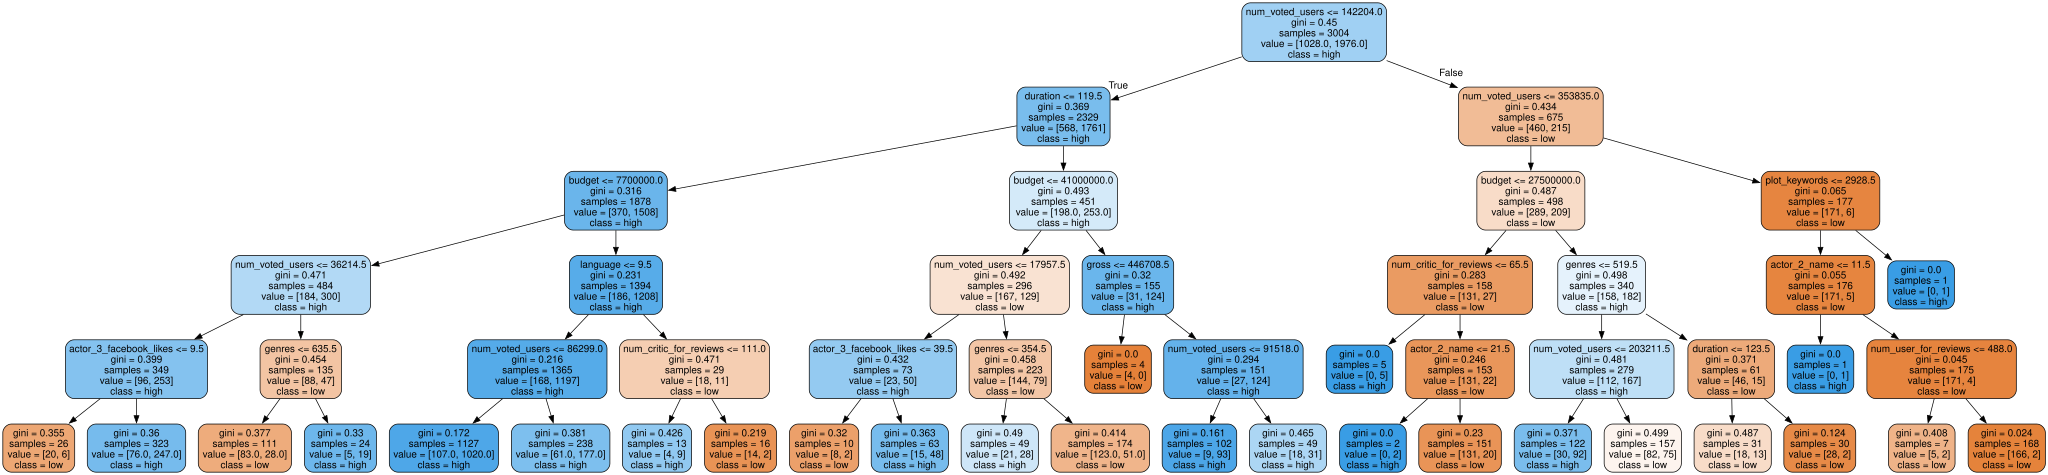

In [94]:
# Visualize the best decision tree
dot_data = export_graphviz(
    best,
    out_file=None,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    class_names=['low', 'high']
)

graph = graphviz.Source(dot_data)
graph

#The decision tree model was generated using the best hyperparameter (max depth = 5). 
# The model structure shows how different features are used to 
# split the data into high- and low-rated movies. 
# The top splits represent the most important decision rules.

In [95]:
# Print best decision tree model
print(best)

DecisionTreeClassifier(max_depth=5, random_state=1000)


14 View the results, comment on how the model performed using the metrics you selected.

In [96]:
# Mean scores across folds
auc = model.cv_results_['mean_test_roc_auc']
recall = model.cv_results_['mean_test_recall']
bal_acc = model.cv_results_['mean_test_balanced_accuracy']

# Standard deviations
SDauc = model.cv_results_['std_test_roc_auc']
SDrecall = model.cv_results_['std_test_recall']
SDbal_acc = model.cv_results_['std_test_balanced_accuracy']

# Depth values
depth = model.cv_results_['param_max_depth']

In [97]:
# create results table
final_model = pd.DataFrame({
    "depth": depth,
    "auc": auc,
    "recall": recall,
    "bal_acc": bal_acc,
    "aucSD": SDauc,
    "recallSD": SDrecall,
    "bal_accSD": SDbal_acc
})

print(final_model)

    depth       auc    recall   bal_acc     aucSD  recallSD  bal_accSD
0       1  0.653441  0.901101  0.653441  0.025768  0.031390   0.025768
1       2  0.706899  0.899685  0.653513  0.026480  0.032421   0.025815
2       3  0.766356  0.893021  0.680159  0.030740  0.039686   0.026028
3       4  0.787100  0.875115  0.719631  0.025150  0.030554   0.027977
4       5  0.802142  0.866612  0.733090  0.023706  0.035819   0.027884
5       6  0.801016  0.876229  0.729042  0.025143  0.028809   0.027388
6       7  0.787243  0.871055  0.732779  0.029404  0.026687   0.024553
7       8  0.767849  0.858605  0.729007  0.031608  0.027225   0.022966
8       9  0.749890  0.852737  0.730645  0.035353  0.025710   0.027183
9      10  0.738418  0.844128  0.733921  0.037654  0.022170   0.025634
10     11  0.729553  0.839978  0.734763  0.035757  0.022109   0.023060


The model performance improved as tree depth increased from 1 to 5, with ROC AUC rising from 0.65 to about 0.80. After depth 5, performance stopped improving and began to slightly decline, suggesting that deeper trees do not generalize as well and may start to overfit.

Recall is relatively high across all depths, meaning the model is good at identifying high-rated movies. Balanced accuracy also improves up to depth 5 and then stabilizes.

Overall, a depth of 5 provides the best balance between model performance and complexity.

15 Which variables appear to be contributing the most (variable importance) 

In [98]:
varimp = pd.DataFrame(
    best.feature_importances_,
    index=X.columns,
    columns=["importance"]
).sort_values("importance", ascending=False)

print(varimp.head(10))

                        importance
num_voted_users           0.566171
budget                    0.184570
duration                  0.086159
genres                    0.055454
actor_3_facebook_likes    0.035603
language                  0.026119
num_critic_for_reviews    0.021759
gross                     0.009761
actor_2_name              0.009045
plot_keywords             0.003487


The variable **importance** results show that **num_voted_users** is by far the most important feature, meaning the number of users who rated a movie strongly influences whether it is classified as high- or low-rated.

Other important variables include budget and duration, suggesting that higher-budget and longer movies may be associated with higher IMDb scores.

Variables such as genres, actor social media presence, and language also contribute to the model, but to a lesser extent. Overall, the model relies heavily on popularity-related features and some production characteristics to make predictions.

One limitation is that variables like num_voted_users may reflect popularity after release rather than intrinsic movie quality, which could limit the model’s usefulness for predicting future movies.

16 Use the predict method on the tune data and print out the results.

In [99]:
# Predict on tuning data
y_pred_tune = best.predict(X_tune)

print(y_pred_tune[:10])

[0. 1. 1. 1. 1. 1. 1. 1. 1. 0.]


17 How does the model perform on the tune data?

In [104]:
# Accuracy
acc = accuracy_score(y_tune, y_pred_tune)

# Recall (important if detecting "high" movies is your goal)
rec = recall_score(y_tune, y_pred_tune)

# Balanced accuracy (handles class imbalance)
bal_acc = balanced_accuracy_score(y_tune, y_pred_tune)

print("Accuracy:", acc)
print("Recall:", rec)
print("Balanced Accuracy:", bal_acc)

Accuracy: 0.776
Recall: 0.9149797570850202
Balanced Accuracy: 0.7113961285425101


On the tuning data, the model has an accuracy of 0.776, meaning it correctly classifies about 77.6% of movies. The recall is 0.915, which suggests the model is able to identify many of the high-rated movies. However, the balanced accuracy is lower at 0.711, meaning the model does not perform equally well across both classes. Overall, the model performs reasonably well, but accuracy alone should not be overinterpreted because the classes are somewhat imbalanced.

18 Print out the confusion matrix for the tune data, what does it tell you about the model?

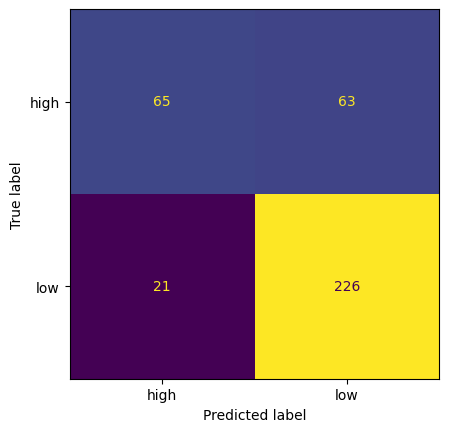

In [106]:
# Confusion matrix for tune data
# This shows correct and incorrect predictions for low and high movies

ConfusionMatrixDisplay.from_estimator(
    best,
    X_tune,
    y_tune,
    display_labels=["high", "low"],
    colorbar=False
)

The confusion matrix shows that the model correctly classified 65 high-rated movies and 226 low-rated movies. It incorrectly classified 63 high-rated movies as low and 21 low-rated movies as high. This means the model is better at identifying low-rated movies than high-rated movies. Even though the model has decent overall accuracy, it still misses a substantial number of high-rated movies, so it should not be treated as a perfect tool for predicting future high IMDb scores.

19 What are the top 3 movies based on the tune set? Which variables are most important in predicting the top 3 movies?

In [110]:
# Reload only the movie titles from the original file
movie_titles = pd.read_csv("movie_metadata.csv")[["movie_title"]]

# Find which column in predict_proba corresponds to the high class
# In our encoding, high = 0.0 and low = 1.0
high_class_index = list(best.classes_).index(0.0)

# Get probability that each tune movie is high-rated
tune_high_prob = best.predict_proba(X_tune)[:, high_class_index]

# Create results dataframe for the tune set
tune_results = movie_titles.loc[X_tune.index].copy()

# Add predicted probability and actual class
tune_results["predicted_high_probability"] = tune_high_prob
tune_results["actual_class"] = y_tune

# Sort by highest predicted probability of being high-rated
top_3_movies = tune_results.sort_values(
    "predicted_high_probability",
    ascending=False
).head(3)

print(top_3_movies)

                   movie_title  predicted_high_probability  actual_class
120             Batman Begins                     0.988095           0.0
1137                     Argo                     0.988095           0.0
48    Star Trek Into Darkness                     0.988095           0.0


The top 3 movies in the tuning set were Batman Begins, Argo, and Star Trek Into Darkness. Each had a predicted high-rating probability of 0.988, meaning the model classified them as very likely to be high-rated movies. Their actual class was also 0.0, which corresponds to the high-rated class, so the model correctly identified these top movies.

The most important variables contributing to these predictions were num_voted_users, budget, and duration. This means the model mostly relied on audience engagement and production-related features when predicting the top high-rated movies. However, num_voted_users may not be available before a movie is released, so this model should be used carefully for predicting future movies.

20 Use a different hyperparameter for the grid search function and go through the process above again using the tune set. 

I selected min_samples_split as the second hyperparameter because it controls how easily the tree creates new splits. While max_depth limits how deep the tree grows, min_samples_split ensures that splits only occur when there is enough data to support them. This helps reduce overfitting by preventing the model from creating very small, overly specific branches. Testing this parameter allows me to explore a different way of controlling model complexity.

In [119]:
# Define new parameter grid
param_grid = {
    "min_samples_split": [2, 5, 10, 20, 50]
}

# Create a new decision tree (same as before)
dt2 = DecisionTreeClassifier(random_state=1000)

# Grid search using SAME kfold + SAME scoring
grid2 = GridSearchCV(
    dt2,
    param_grid,
    cv=kf,
    scoring=scoring,
    n_jobs=-1,
    refit="roc_auc"
)

# Fit on training data
grid2.fit(X_train, y_train)

# Best model
best2 = grid2.best_estimator_

print("Best min_samples_split:", grid2.best_params_)

Best min_samples_split: {'min_samples_split': 50}


In [120]:
# Predict
y_pred_tune2 = best2.predict(X_tune)

# Metrics
print("Accuracy:", accuracy_score(y_tune, y_pred_tune2))
print("Recall:", recall_score(y_tune, y_pred_tune2))
print("Balanced Accuracy:", balanced_accuracy_score(y_tune, y_pred_tune2))

Accuracy: 0.6933333333333334
Recall: 0.7408906882591093
Balanced Accuracy: 0.6712265941295547


21 Did the model improve with the new hyperparameter search?

The model did not improve after introducing the min_samples_split hyperparameter. The new model resulted in lower accuracy (0.693), lower recall (0.741), and lower balanced accuracy (0.671) compared to the original model. This indicates that increasing the minimum number of samples required to split made the tree too simple, reducing its ability to capture important patterns in the data. Therefore, the original model with max_depth = 5 performs better.

22 Using the better model, predict the test data and print out the results.

In [121]:
# Use the better model to predict the test data
y_pred_test = best.predict(X_test)

# Print first few test predictions
print(y_pred_test[:10])

# Evaluate test performance
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test Recall:", recall_score(y_test, y_pred_test))
print("Test Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_test))

[1. 0. 1. 0. 0. 0. 1. 1. 0. 1.]
Test Accuracy: 0.7712765957446809
Test Recall: 0.9068825910931174
Test Balanced Accuracy: 0.7092552490349309


Using the better model (max_depth = 5), the model achieved a test accuracy of 0.771, recall of 0.907, and balanced accuracy of 0.709. These results are very similar to the tuning set performance, indicating that the model generalizes well to unseen data and is not heavily overfitting. The model maintains high recall, meaning it is effective at identifying high-rated movies, but the balanced accuracy remains lower, suggesting that performance across classes is still uneven. Overall, the model performs consistently but still shows some bias in classification.

23 Summarize what you learned along the way and make recommendations to your boss on how this could be used moving forward, being careful not to over promise.

Throughout this project, I learned how to take a real-world dataset and move through the full data science workflow, from cleaning messy data to building and evaluating a predictive model. One of the biggest takeaways was how important preprocessing is. A lot of the work was not even the model itself, but making sure variables were the correct type, handling missing values, and properly encoding categorical features without introducing data leakage.

Using a decision tree was helpful because it is interpretable. I was able to clearly see which variables mattered most, and it was interesting that features like number of voted users, budget, and duration had the strongest influence on predictions. This makes sense since these variables are tied to popularity and production scale, which often relate to higher ratings.

In terms of performance, the model was fairly consistent across training, tuning, and test datasets, which suggests it generalizes reasonably well. It achieved high recall, meaning it was good at identifying high-rated movies, but the balanced accuracy showed that it struggled to treat both classes equally. The confusion matrix made it clear that the model is somewhat conservative and misses a noticeable number of high-rated movies.

When I experimented with a different hyperparameter, min_samples_split, the model performance actually decreased. This reinforced that max_depth was the better tuning parameter in this case.

Overall, this model could be useful as a screening tool for the studio. It can help flag movies that are likely to perform well, but it should not be used as a final decision-maker. There are many factors that influence movie success that are not captured in this dataset, such as marketing, release timing, and audience trends.

Moving forward, I would recommend improving the model by trying additional methods like random forests, engineering more meaningful features, and possibly redefining what “high” means to better balance the classes. This would help create a more reliable and actionable prediction system.